# 7. Swarm

![Swarm](docs/langchain_swarm.png)

In [1]:
from langchain_openai import AzureChatOpenAI
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.prebuilt import create_react_agent
from langgraph_swarm import create_handoff_tool, create_swarm
from datetime import date

Define the model

In [2]:
llm = AzureChatOpenAI(model="gpt-4.1-mini")

Define tools that will be needed by the agent

In [3]:
def book_hotel(destination: str, nights: int, start_date: date) -> str:
    """Book a hotel for a given destination and number of nights"""
    return f"Hotel booked in {destination} for {nights} nights starting from {start_date}. Booking Code: HLT123"


def get_hotels(destination: str, start_date: date) -> list[str]:
    """Get available hotels for a given destination and start date"""
    return ["Holiday Inn", "Marriott", "Hilton"]


def get_flights_available(origin: str, destination: str, date: date) -> list[str]:
    """Get available flights from origin to destination on a specific date"""
    return ["Flight QF32", "Flight QF4", "Flight QF128"]


def book_flight(flight_no: str, date: date) -> str:
    """Book a flight from one location to another on a specific date"""
    return f"Flight {flight_no} booked on {date}, Booking Code: FLY123"


def book_event(event_name: str, date: date) -> str:
    """Book an event ticket for a specific event on a specific date"""
    return f"Ticket booked for {event_name} on {date}. Ticket Code: EVT123"

We need to create extra tools that define what other agents are able to do, so they can hand off to each one of them.

These tools need to be given to each agent as extras

In [4]:
hand_off_tools = [
    create_handoff_tool(
        agent_name="HotelBookingAgent",
        description="Transfer to Hotel Booking Agent for hotel-related queries",
    ),
    create_handoff_tool(
        agent_name="FlightBookingAgent",
        description="Transfer to Flight Booking Agent for flight-related queries",
    ),
    create_handoff_tool(
        agent_name="EventBookingAgent",
        description="Transfer to Event Booking Agent for event-related queries",
    ),
]

Create Hotel Booking Agent

In [5]:
tools = [book_hotel, get_hotels]
tools.extend(hand_off_tools)

hotel_booking_agent = create_react_agent(
    model=llm.bind_tools(tools, parallel_tool_calls=False),
    tools=tools,
    prompt="You are a hotel booking agent. You can book hotels and check availability.",
    name="HotelBookingAgent",
)

Create Flight Booking Agent

In [6]:
tools = [book_flight, get_flights_available]
tools.extend(hand_off_tools)

flight_booking_agent = create_react_agent(
    model=llm.bind_tools(tools, parallel_tool_calls=False),
    tools=tools,
    prompt="You are a flight booking agent. You can book flights.",
    name="FlightBookingAgent",
)

Create Event Booking Agent

In [7]:
tools = [book_event]
tools.extend(hand_off_tools)

event_booking_agent = create_react_agent(
    model=llm.bind_tools(tools, parallel_tool_calls=False),
    tools=tools,
    prompt="You are an event booking agent. You can book event tickets.",
    name="EventBookingAgent",
)

Create Swarm

A swarm compared to a supervisor does not need any info of what each agent can do, the agents know that due to the hand off tools.

Notice though that we need to set a default agent. On invocation of the swarm this is the first agent that will be called and will decide what the next steps will be.

In [8]:
checkpointer = InMemorySaver()
workflow = create_swarm(
    [hotel_booking_agent, flight_booking_agent, event_booking_agent],
    default_active_agent="HotelBookingAgent",
)
app = workflow.compile(checkpointer=checkpointer)

Printing out the workflow diagram

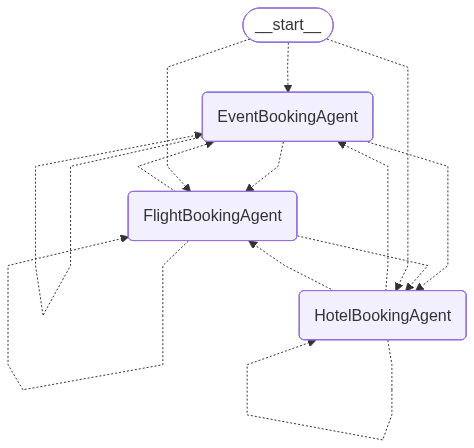

In [9]:
from IPython.display import Image

Image(app.get_graph().draw_mermaid_png())

![Swarm](docs/swarm.png)

Executing the workflow

```
I need your help in a trip to Perth. I need a hotel for 14 nights, a flight from London to Perth on 2025-08-01, and tickets for the Corteo show of Cirque du Soleil on 2028-08-10.
```

In [10]:
config = {"configurable": {"thread_id": "1"}}
input_msg = input()
while input_msg.lower() != "exit" or len(input_msg) == 0:
    async for event in app.astream(
        {"messages": [{"role": "user", "content": input_msg}]},
        config,
        stream_mode="updates",
    ):
        for agent in hand_off_tools:
            for msg in event.get(agent.metadata["__handoff_destination"], {}).get(
                "messages", []
            ):
                msg.pretty_print()

    input_msg = input()

================================ Human Message =================================

I need your help in a trip to Perth. I need a hotel for 14 nights, a flight from London to Perth on 2025-08-01, and tickets for the Corteo show of Cirque du Soleil on 2028-08-10.
================================== Ai Message ==================================
Name: HotelBookingAgent
Tool Calls:
  get_hotels (call_BdJsvwMkdmQkaOuiM3fjbDSW)
 Call ID: call_BdJsvwMkdmQkaOuiM3fjbDSW
  Args:
    destination: Perth
    start_date: 2025-08-01
================================= Tool Message =================================
Name: get_hotels

["Holiday Inn", "Marriott", "Hilton"]
================================== Ai Message ==================================
Name: HotelBookingAgent

For your trip to Perth starting on 2025-08-01, the available hotels are Holiday Inn, Marriott, and Hilton. Which one would you like to book for 14 nights?
================================ Human Message =================================


I need your help in a trip to Perth. I need a hotel for 14 nights, a flight from London to Perth on 2025-08-01, and tickets for the Corteo show of Cirque du Soleil on 2028-08-10.